In [ ]:
from pathlib import Path
import spatialdata as sd
import pandas as pd
import json
import numpy as np
from IPython.display import display
from tqdm.notebook import tqdm
import pickle
import gc
import os

from xenium_analysis_tools.utils.sd_utils import (
    get_dataset_paths,
)

from xenium_analysis_tools.alignment.align_sections import (
    get_microns_scales,
)

root_path = Path('/root/capsule')

## Define dataset and base paths

In [4]:
# Mouse ID
dataset_id = 756772

# Paths for dataset
paths = get_dataset_paths(dataset_id, 
                data_root=root_path / 'data',
                scratch_root=root_path / 'scratch',
                results_root=root_path / 'results',
                code_root=root_path / 'code')

# Dataset info
datasets_names_dict_path = root_path / 'code/xenium_analysis_tools/src/xenium_analysis_tools/example_notebooks/datasets_names_dict.json'
with open(datasets_names_dict_path, 'r') as f:
    datasets_names_dict = json.load(f)
dataset_info = datasets_names_dict.get(str(dataset_id), {})  
genotype = dataset_info.get('genotype', None)
sectioning_depth = dataset_info.get('sectioning_depth', None)
sections_um = dataset_info.get('sections_thickness', 20)
print(f"Dataset ID: {dataset_id}")
print(f"Genotype: {genotype}")
print(f"Tissue depth: {sectioning_depth if sectioning_depth is not None else 'Unknown'}")
print(f"Sections depth: {sections_um} µm")

Dataset ID: 756772
Genotype: Slc32a1-IRES-Cre;Oi1
Tissue depth: 450
Sections depth: 20 µm


## Load or create the aligned/combined data

In [5]:
# Output folder for aligned data and landmarks
alignment_folder = Path(paths['scratch_root']) / f'xenium_{dataset_id}_alignment'
alignment_folder.mkdir(parents=True, exist_ok=True)
print(f"Alignment folder at: {alignment_folder}")

combined_data_folder = paths['results_root'] / alignment_folder.name
combined_data_folder.mkdir(parents=True, exist_ok=True)
combined_data_path = combined_data_folder / 'combined_data.zarr'

print(f"Combined data path at: {combined_data_path}")

Alignment folder at: /root/capsule/scratch/xenium_756772_alignment
Combined data path at: /root/capsule/results/xenium_756772_alignment/combined_data.zarr


In [6]:
if not combined_data_path.exists():
    print("Generating combined SpatialData object...")
    czstack_path = alignment_folder / 'zstacks' / 'zstack.zarr'
    sections_landmarks_path = alignment_folder / 'affines' / 'sections_landmarks.pkl'
    sections_affines_path = alignment_folder / 'affines' / 'sections_affines.pkl'

    from xenium_analysis_tools.alignment.align_sections import (
        align_section_to_zstack, 
        format_czstack, 
        print_sdata_size_summary, 
        write_sdata_elements
    )
    czstack_sdata = sd.read_zarr(czstack_path)
    czstack_microns_scale_tf = get_microns_scales(czstack_sdata, 'zstack')

    with open(sections_landmarks_path, 'rb') as f:
        sections_landmarks = pickle.load(f)
    with open(sections_affines_path, 'rb') as f:
        sections_affines = pickle.load(f)

    print("Aligning all sections to cortical z-stack coordinate space...")
    xenium_section_ns = sorted([int(sd_path.stem.split('_')[1]) for sd_path in list(paths['sdata_path'].glob('*.zarr'))])
    all_sections = {}
    for s_n in tqdm(xenium_section_ns, desc='Processing sections', unit='section'):
        if s_n not in sections_affines.keys():
            print(f"No affine transforms associated with section {s_n}")
            continue
        section_sdata = sd.read_zarr(paths['sdata_path'] / f'section_{s_n}.zarr')
        sdata = align_section_to_zstack(sdata=section_sdata,
                                        czstack_sdata=czstack_sdata,
                                        affines=sections_affines[s_n],
                                        landmarks=sections_landmarks[s_n],
                                        section_n=s_n,
                                        czstack_microns_scale_tf=czstack_microns_scale_tf)
        all_sections[s_n] = sdata
        del sdata
        gc.collect()
    
    print("Concatenating sections...")
    combined_data = sd.concatenate(all_sections, merge_coordinate_systems_on_name=True, 
                                    obs_names_make_unique=True, concatenate_tables=True)
    del all_sections
    gc.collect()
    print("Formatting cortical z-stack...")
    czstack_sdata = format_czstack(czstack_sdata)
    print("Combining cortical z-stack with sections...")
    combined_data = sd.concatenate([czstack_sdata, combined_data])

    print_sdata_size_summary(combined_data)

    write_sdata_elements(sdata=combined_data, 
                        sdata_path=combined_data_path,
                        overwrite=False,
                        num_workers=os.cpu_count())
    del combined_data
    gc.collect()
    combined_data = sd.read_zarr(combined_data_path)
else:
    combined_data = sd.read_zarr(combined_data_path)

Generating combined SpatialData object...
Aligning all sections to cortical z-stack coordinate space...


Processing sections:   0%|          | 0/21 [00:00<?, ?section/s]

/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


No affine transforms associated with section 17
No affine transforms associated with section 18
No affine transforms associated with section 19
No affine transforms associated with section 20
No affine transforms associated with section 21
Concatenating sections...
Formatting cortical z-stack...
Combining cortical z-stack with sections...

=== Combined SpatialData size summary ===

  [images]
    gcamp : 0.94 GB
    dapi_zstack (16 sections): 3.80 GB
    morphology_focus (16 sections): 1.38 GB

  [labels]
    gcamp_labels : 0.24 GB
    cell_labels (16 sections): 0.69 GB

  [points]
    transcripts (16 sections): 0.00 GB
    landmarks (16 sections): 0.00 GB

  [tables]
    gcamp_table : 0.00 GB
    table : 0.21 GB

  Total (uncompressed, in-memory): 7.27 GB
  On-disk (zarr, ~3-5x compression): ~1.82–2.42 GB estimated

Writing 84 elements...


/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/src/spatialdata/src/spatialdata/models/models.py:1235: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


Writing elements:   0%|          | 0/84 [00:00<?, ?element/s]

  [images] gcamp...
    done in 4.0s
  [images] dapi_zstack-1...
    done in 0.6s
  [images] morphology_focus-1...
    done in 0.2s
  [images] dapi_zstack-2...
    done in 0.6s
  [images] morphology_focus-2...
    done in 0.3s
  [images] dapi_zstack-3...
    done in 0.6s
  [images] morphology_focus-3...
    done in 0.3s
  [images] dapi_zstack-4...
    done in 0.6s
  [images] morphology_focus-4...
    done in 0.3s
  [images] dapi_zstack-5...
    done in 0.8s
  [images] morphology_focus-5...
    done in 0.4s
  [images] dapi_zstack-6...
    done in 0.8s
  [images] morphology_focus-6...
    done in 0.4s
  [images] dapi_zstack-7...
    done in 0.8s
  [images] morphology_focus-7...
    done in 0.4s
  [images] dapi_zstack-8...
    done in 1.2s
  [images] morphology_focus-8...
    done in 0.5s
  [images] dapi_zstack-9...
    done in 1.2s
  [images] morphology_focus-9...
    done in 0.7s
  [images] dapi_zstack-10...
    done in 1.0s
  [images] morphology_focus-10...
    done in 0.6s
  [images] 

no parent found for <ome_zarr.reader.Label object at 0x7ff3a811ac30>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff38ccfbda0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff3c4226750>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff37abfd4f0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff37bf33140>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff4042319d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff404231910>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff3a811aa80>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff38d7cdac0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff38cae8fe0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff38d733f80>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff38d733b00>: None
no parent found for <ome_zarr.reader.Label object at 0x7ff38c3dd4f0>: None
no parent found for <ome_

In [7]:
combined_data

SpatialData object, with associated Zarr store: /results/xenium_756772_alignment/combined_data.zarr
├── Images
│     ├── 'dapi_zstack-1': DataArray[czyx] (1, 11, 2586, 2162)
│     ├── 'dapi_zstack-2': DataArray[czyx] (1, 11, 2586, 2870)
│     ├── 'dapi_zstack-3': DataArray[czyx] (1, 11, 2590, 2877)
│     ├── 'dapi_zstack-4': DataArray[czyx] (1, 11, 2590, 2877)
│     ├── 'dapi_zstack-5': DataArray[czyx] (1, 11, 3435, 2882)
│     ├── 'dapi_zstack-6': DataArray[czyx] (1, 11, 2591, 3584)
│     ├── 'dapi_zstack-7': DataArray[czyx] (1, 11, 2595, 3584)
│     ├── 'dapi_zstack-8': DataArray[czyx] (1, 11, 3434, 3590)
│     ├── 'dapi_zstack-9': DataArray[czyx] (1, 11, 3434, 4292)
│     ├── 'dapi_zstack-10': DataArray[czyx] (1, 11, 2591, 4293)
│     ├── 'dapi_zstack-11': DataArray[czyx] (1, 11, 3439, 3590)
│     ├── 'dapi_zstack-12': DataArray[czyx] (1, 11, 2590, 3585)
│     ├── 'dapi_zstack-13': DataArray[czyx] (1, 11, 3434, 3590)
│     ├── 'dapi_zstack-14': DataArray[czyx] (1, 11, 3434, 4292)
│ 

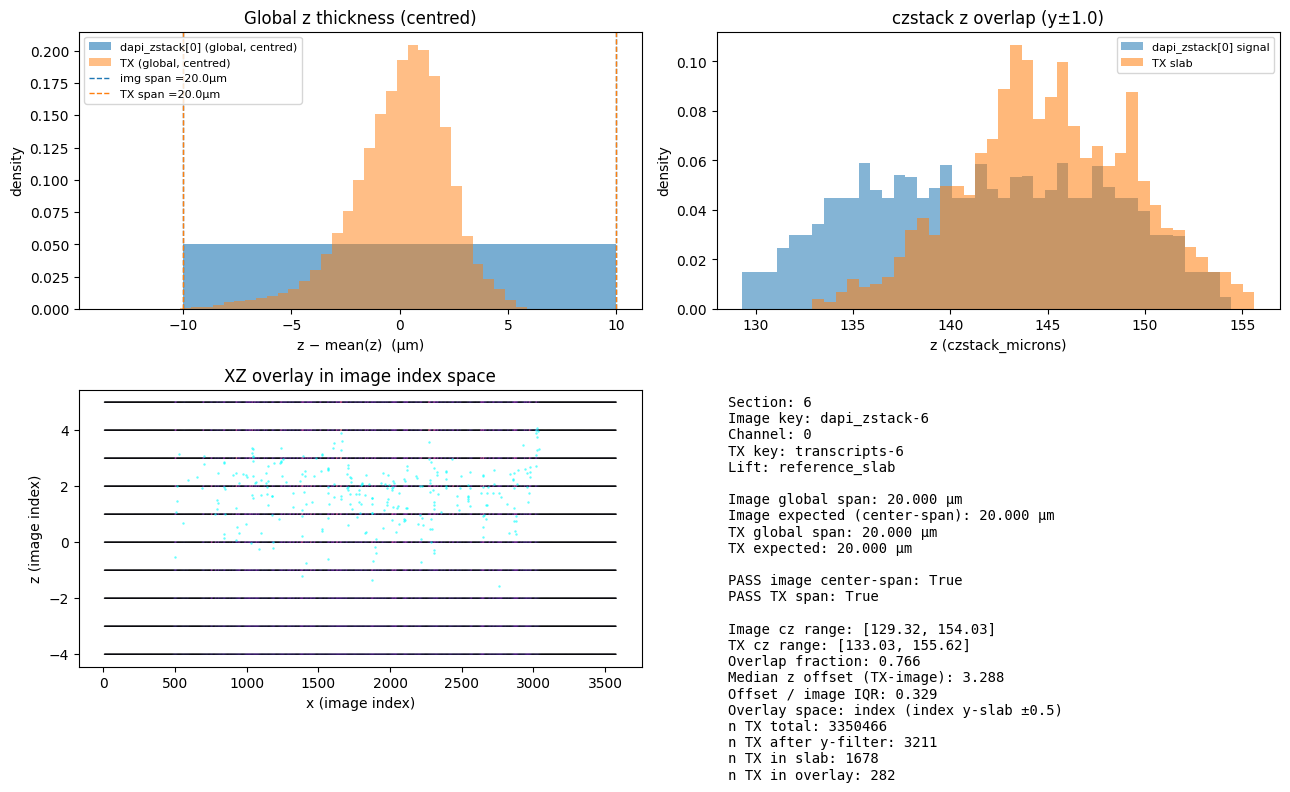

Section 6  | image=dapi_zstack-6  tx=transcripts-6
n_tx=3350466  n_z_image=11  lift_mode=reference_slab
z_ref_n_planes=11  z_lift_start=0.0
Slab bounds (centered idx space): [-5.0, 5.0]
z_idx min/max: -5.000 / 5.000
out_of_slab: 1 (0.000%)  [low=0, high=1]
{'section_n': 6, 'img_key': 'dapi_zstack-6', 'tx_key': 'transcripts-6', 'n_tx': 3350466, 'n_z_image': 11, 'lift_mode': 'reference_slab', 'z_ref_n_planes': 11, 'z_lift_start': 0.0, 'z_slab_lo': -5.0, 'z_slab_hi': 5.0, 'z_idx_min': -5.0, 'z_idx_max': 5.000000000000014, 'out_of_slab_n': 1, 'out_of_slab_fraction': 2.9846594473723953e-07}


In [8]:
from xenium_analysis_tools.alignment.align_sections import alignment_qc_dashboard, diagnose_transcript_z_within_section
alignment_qc_dashboard(combined_data,
                        section_n=6,
                        img_key_type='dapi_zstack')

section_n=6
z_diag = diagnose_transcript_z_within_section(
    combined_data,
    section_n=section_n,
    img_key_type='dapi_zstack',
    coord_sys='czstack_microns',
)
print(z_diag)